Decision Tree

Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

Data Preparation

Load Dataset

In [ ]:
df = pd.read_excel("/content/heart_disease.xlsx", sheet_name="Heart_disease")

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


Dataset Information

In [ ]:
print(df.shape)
df.info()
df.describe(include='all')

(908, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
count,908.000000,908,908,908.000000,908.000000,908,908,908.000000,908,846.000000,908,908,908.000000
unique,NaN,2,4,NaN,NaN,2,3,NaN,4,NaN,3,3,NaN
top,NaN,Male,asymptomatic,NaN,NaN,False,normal,NaN,False,NaN,flat,reversable defect,NaN
freq,NaN,718,495,NaN,NaN,723,542,NaN,516,NaN,453,372,NaN
mean,53.791850,NaN,NaN,133.430617,201.484581,NaN,NaN,135.957048,NaN,0.891253,NaN,NaN,1.008811
std,9.158031,NaN,NaN,20.401608,112.097949,NaN,NaN,26.804929,NaN,1.093875,NaN,NaN,1.144436
min,29.000000,NaN,NaN,0.000000,0.000000,NaN,NaN,60.000000,NaN,-2.600000,NaN,NaN,0.000000
25%,47.750000,NaN,NaN,120.000000,176.750000,NaN,NaN,118.000000,NaN,0.000000,NaN,NaN,0.000000
50%,54.000000,NaN,NaN,130.000000,224.000000,NaN,NaN,138.000000,NaN,0.500000,NaN,NaN,1.000000
75%,60.000000,NaN,NaN,144.000000,270.000000,NaN,NaN,156.000000,NaN,1.500000,NaN,NaN,2.000000


Exploratory Data Analysis

In [ ]:
print(df.isnull().sum())

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64


Check Duplicate Records


In [ ]:
print("Duplicate rows :", df.duplicated().sum())

Duplicate rows : 1


Histograms

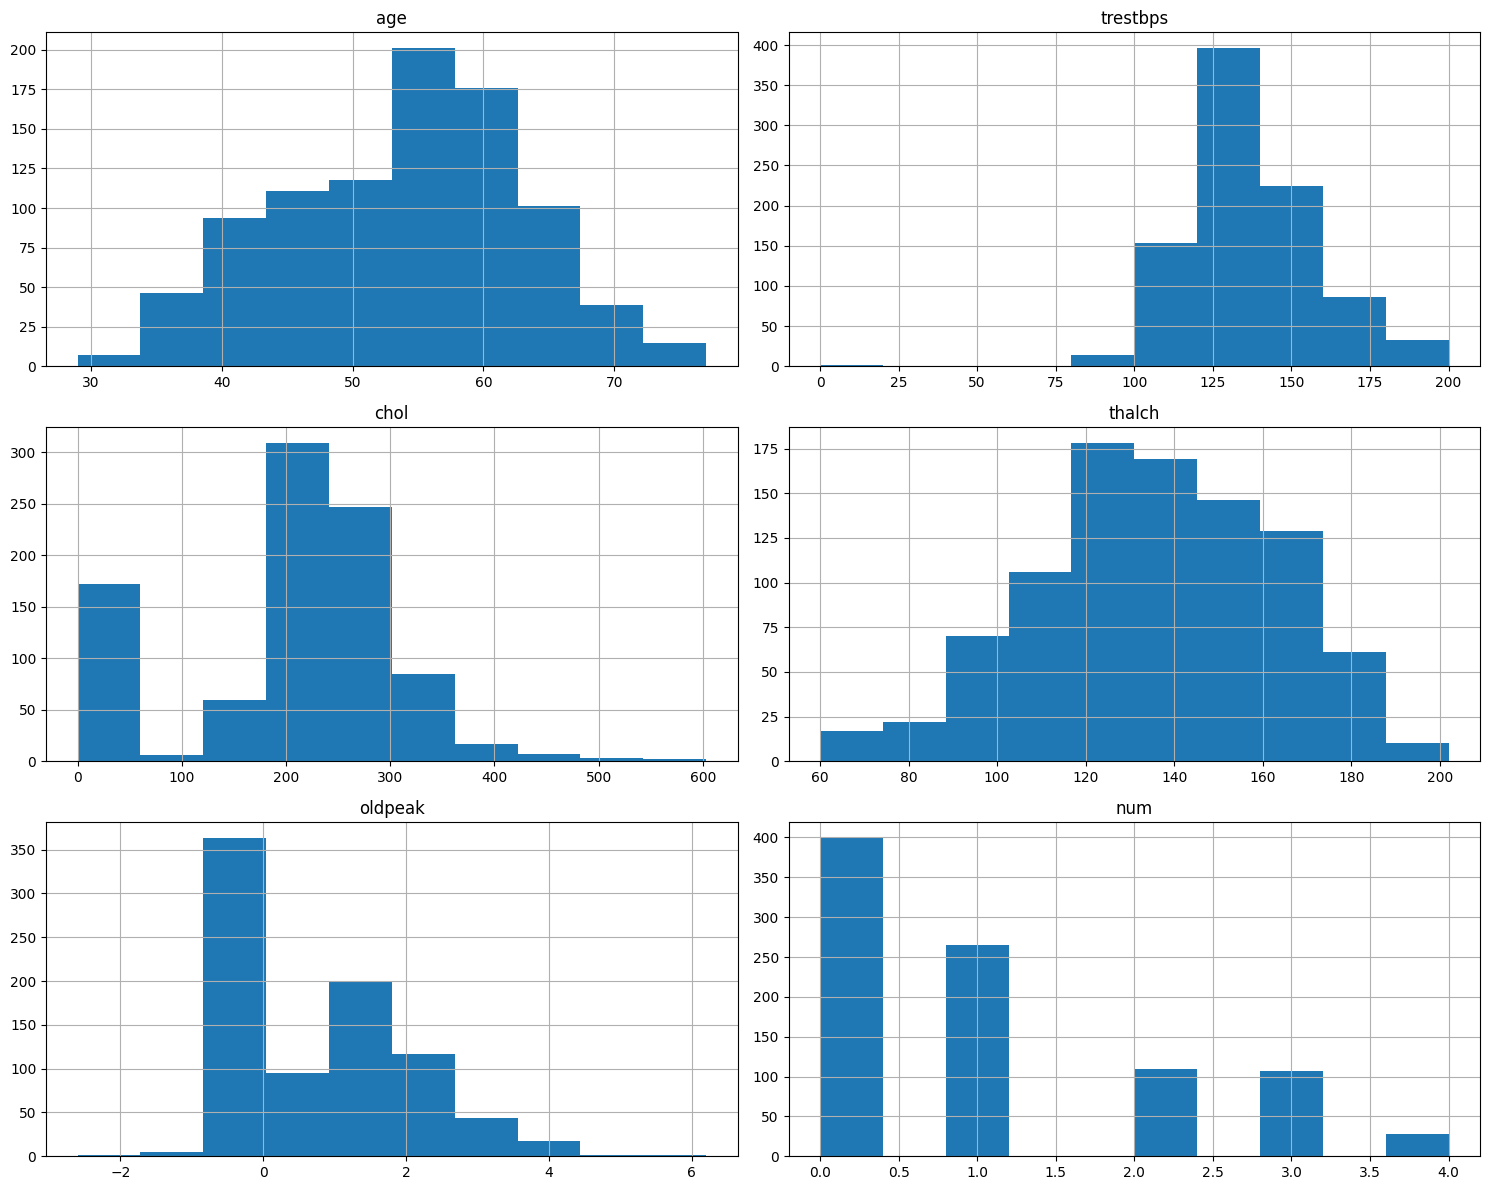

In [ ]:
df.hist(figsize=(15,12))
plt.tight_layout()
plt.show()

Boxplots

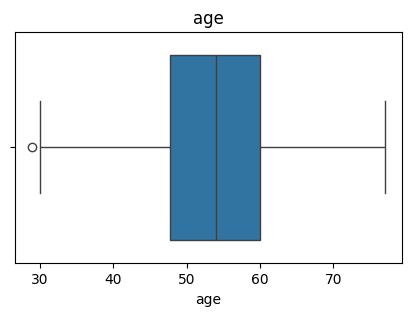

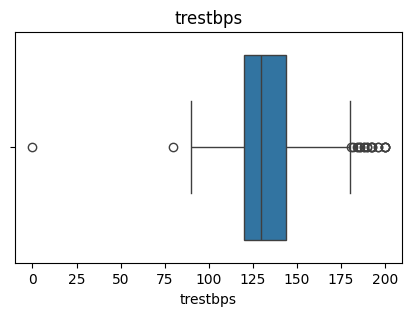

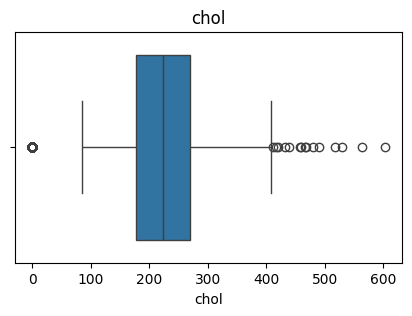

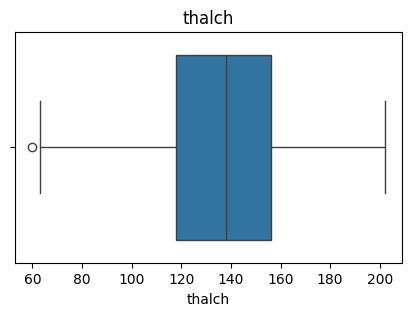

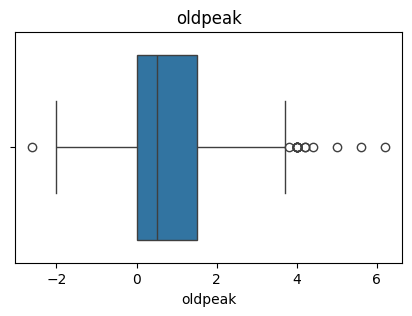

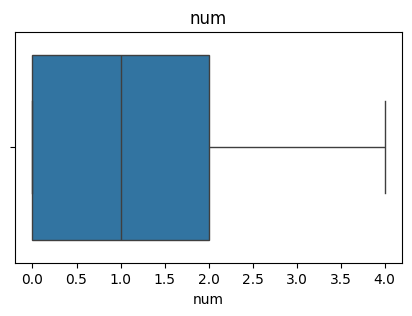

In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

Correlation Matrix

Before correlation, encode categorical columns.

In [ ]:
eda_df = df.copy()
le = LabelEncoder()

for col in eda_df.select_dtypes(include='object').columns:
    # Convert all values in the column to string type before encoding
    eda_df[col] = le.fit_transform(eda_df[col].astype(str))

# The fbs column is already boolean and can be converted to int directly
eda_df["fbs"] = eda_df["fbs"].astype(int)

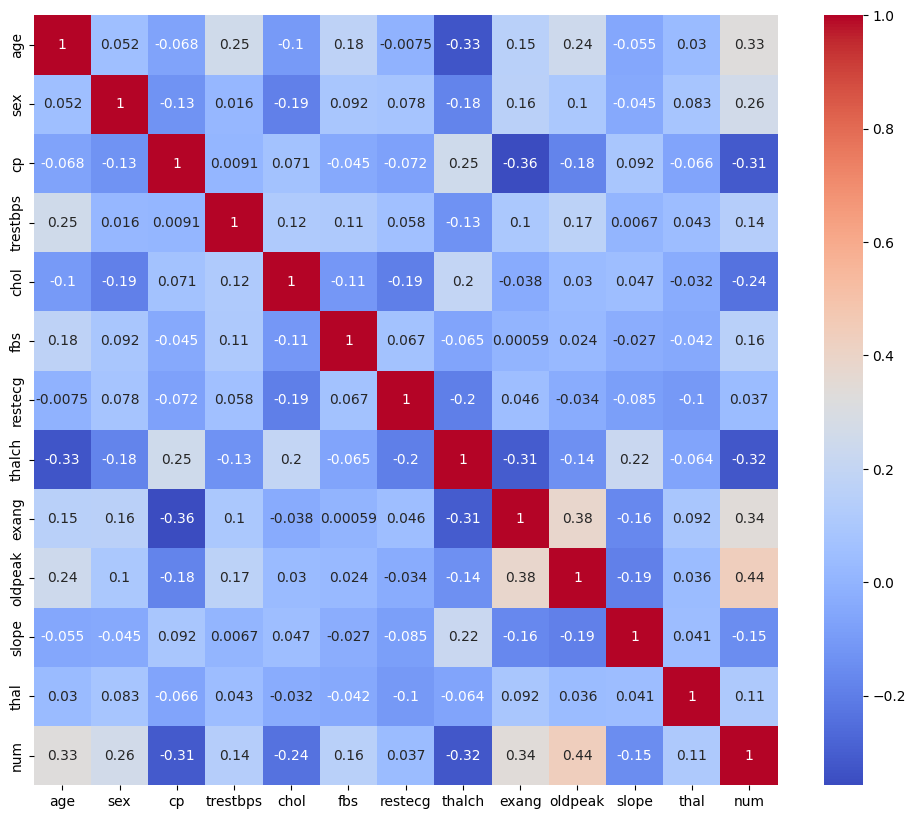

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(eda_df.corr(), annot=True, cmap="coolwarm")
plt.show()

Feature Engineering

Encode Categorical Variables

In [ ]:
df_encoded = df.copy()

label_encoder = LabelEncoder()

for col in df_encoded.select_dtypes(include='object').columns:
    # Convert all values in the column to string type before encoding
    df_encoded[col] = label_encoder.fit_transform(df_encoded[col].astype(str))

df_encoded["fbs"] = df_encoded["fbs"].astype(int)

Features and Target

In [ ]:
X = df_encoded.drop("num", axis=1)
y = df_encoded["num"]

Convert target into binary classification.

In [ ]:
y = y.apply(lambda x: 0 if x==0 else 1)

Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Decision Tree Classification

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

Prediction

In [ ]:
y_pred = dt.predict(X_test)
y_prob = dt.predict_proba(X_test)[:,1]

Evaluation Metrics


In [ ]:
accuracy = accuracy_score(y_test,y_pred)
precision = precision_score(y_test,y_pred)
recall = recall_score(y_test,y_pred)
f1 = f1_score(y_test,y_pred)
roc = roc_auc_score(y_test,y_prob)

print("Accuracy :",accuracy)
print("Precision :",precision)
print("Recall :",recall)
print("F1 Score :",f1)
print("ROC AUC :",roc)

Accuracy : 0.6978021978021978
Precision : 0.7326732673267327
Recall : 0.7254901960784313
F1 Score : 0.729064039408867
ROC AUC : 0.6939950980392157


Confusion Matrix

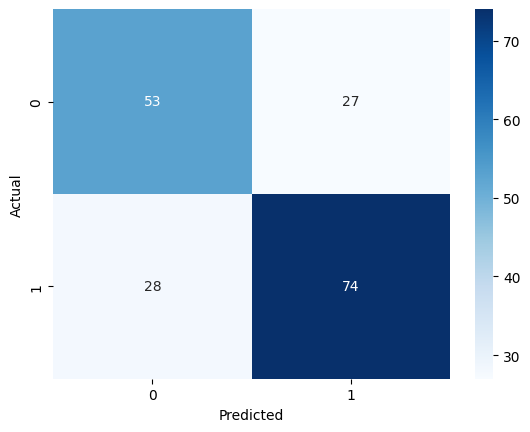

In [ ]:
cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Classification Report

In [ ]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.65      0.66      0.66        80
           1       0.73      0.73      0.73       102

    accuracy                           0.70       182
   macro avg       0.69      0.69      0.69       182
weighted avg       0.70      0.70      0.70       182



ROC Curve

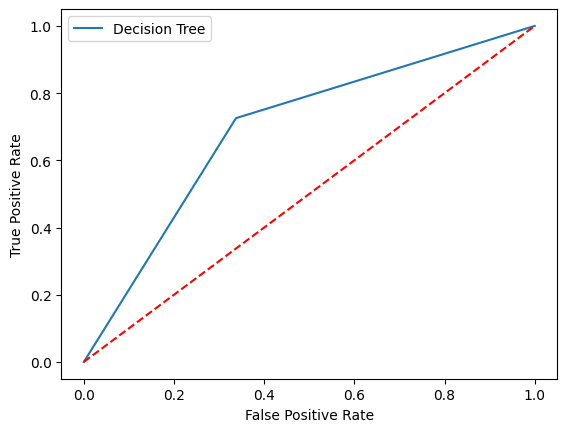

In [ ]:
fpr,tpr,threshold = roc_curve(y_test,y_prob)
plt.plot(fpr,tpr,label="Decision Tree")
plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

Hyperparameter Tuning

In [ ]:
param_grid = {
    "criterion":["gini","entropy"],
    "max_depth":[3,5,7,10,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}

In [ ]:
grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="accuracy"
)

grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, 10, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

Best Parameters

In [ ]:
print(grid.best_params_)

{'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}


Best Model

In [ ]:
best_model = grid.best_estimator_
prediction = best_model.predict(X_test)
probability = best_model.predict_proba(X_test)[:,1]

Accuracy after Tuning

In [ ]:
print("Accuracy :",accuracy_score(y_test,prediction))
print("Precision :",precision_score(y_test,prediction))
print("Recall :",recall_score(y_test,prediction))
print("F1 :",f1_score(y_test,prediction))
print("ROC :",roc_auc_score(y_test,probability))

Accuracy : 0.7142857142857143
Precision : 0.7659574468085106
Recall : 0.7058823529411765
F1 : 0.7346938775510204
ROC : 0.7596200980392157


Model Evaluation & Analysis

Feature Importance

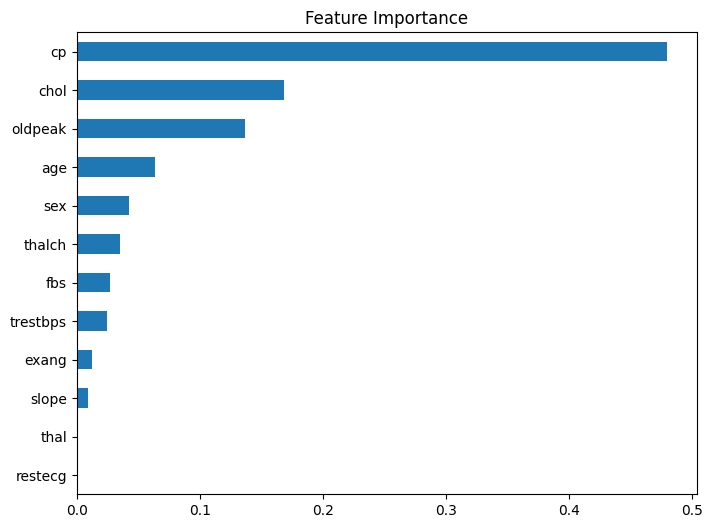

In [ ]:
importance = pd.Series(
    best_model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind="barh",
    figsize=(8,6)
)

plt.title("Feature Importance")
plt.show()




Decision Tree Visualization

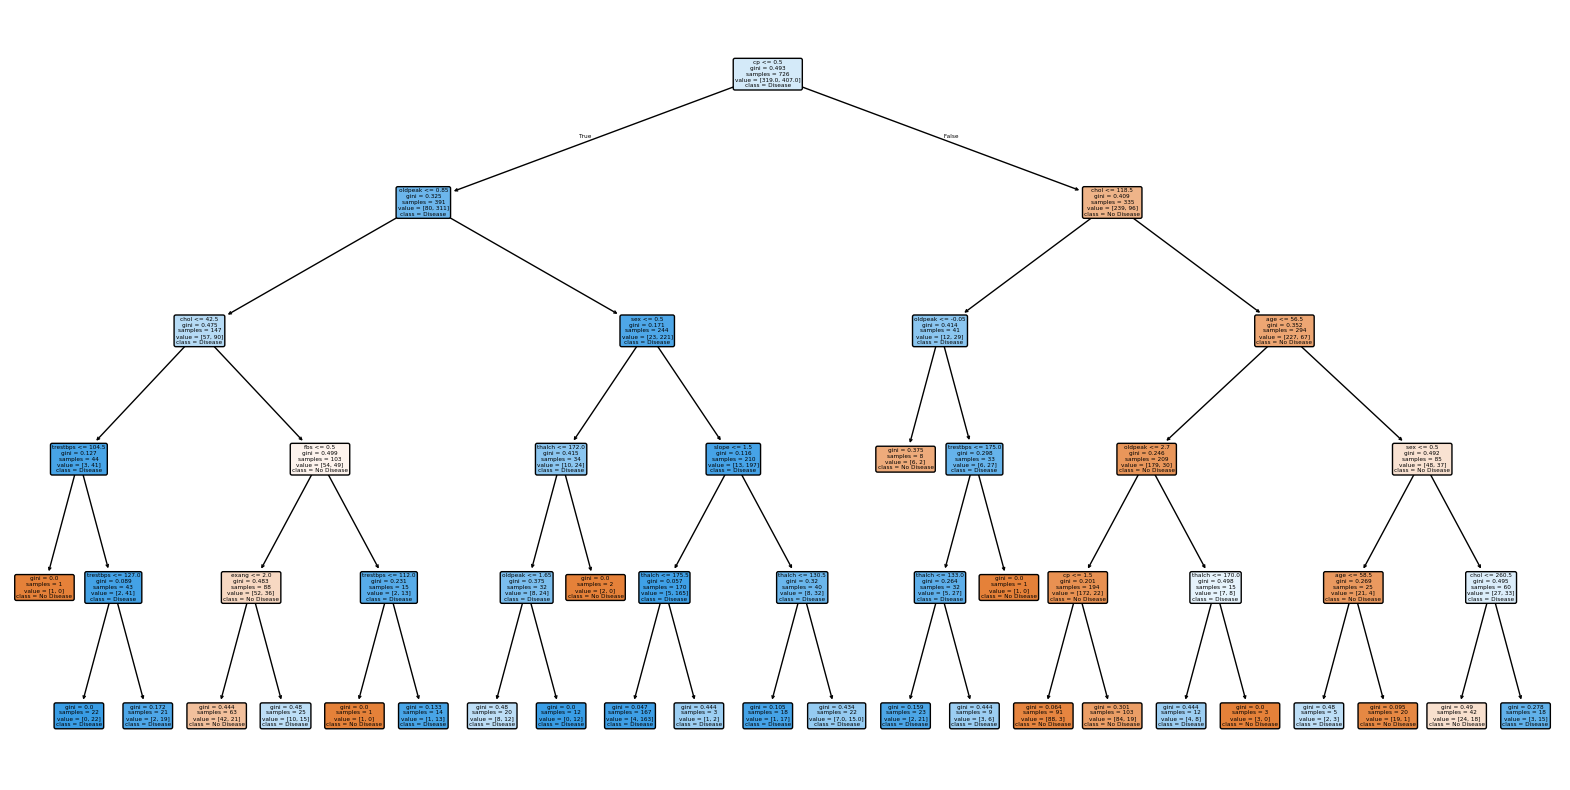

In [ ]:
plt.figure(figsize=(20,10))

plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["No Disease","Disease"],
    filled=True,
    rounded=True
)

plt.show()

Interview Questions:
1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?

"The main hyperparameters of a Decision Tree are:

max_depth: Controls the maximum depth of the tree. A larger depth can lead to overfitting, while a smaller depth can cause underfitting.

min_samples_split: Specifies the minimum number of samples required to split a node. Higher values reduce unnecessary splits and improve generalization.

min_samples_leaf: Sets the minimum number of samples required in a leaf node. It helps prevent overfitting by avoiding very small leaf nodes.

criterion: Determines how the best split is selected. Common options are Gini and Entropy.

max_features: Limits the number of features considered at each split, which can reduce overfitting.

Overall, these hyperparameters control the complexity of the tree and help balance underfitting and overfitting."

2. What is the difference between the Label encoding and One-hot encoding?

"Both techniques convert categorical data into numerical form, but they work differently.

Label Encoding assigns a unique integer to each category. For example, Red = 0, Blue = 1, Green = 2. It is suitable for ordinal data, where categories have a meaningful order, such as Low, Medium, and High.

One-Hot Encoding creates a separate binary column for each category. For example, if the categories are Red, Blue, and Green, it creates three columns, and only one column has a value of 1 for each record. It is suitable for nominal data, where there is no natural order.

In practice, I use Label Encoding for ordered categories and One-Hot Encoding for unordered categories to avoid introducing a false relationship between categories."
